In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [5]:
print(df.head())

   Employee_ID   Age  Gender Department  Education  Experience_Years  \
0         1001  59.0    Male         HR    Masters                18   
1         1002  49.0  Female  Marketing  Bachelors                16   
2         1003  35.0  Female         HR        NaN                19   
3         1004  28.0  Female         HR        PhD                 9   
4         1005  41.0    Male         IT  Bachelors                 5   

   Monthly_Salary  Performance_Rating        City Attrition  
0         52350.0                   5     Calicut        No  
1        118008.0                   2     Chennai       Yes  
2        119297.0                   1       Kochi       Yes  
3         50351.0                   2  Trivandrum       Yes  
4        113668.0                   3  Trivandrum       Yes  


In [6]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [17]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())
df['Department_mode_imputed']=df['Department'].fillna(df['Department'].mode()[0])
df['Monthly_Salary_mean_imputed']=df['Monthly_Salary'].fillna(df['Monthly_Salary'].mean())
df['Education_mode_imputed']=df['Education'].fillna(df['Education'].mode()[0])
df['City_mode_imputed']=df['City'].fillna(df['City'].mode()[0])

In [8]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Education,0
Experience_Years,0
Monthly_Salary,0
Performance_Rating,0
City,0
Attrition,0


/tmp/ipykernel_450/4136455366.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Department',y='Age',palette='pastel')


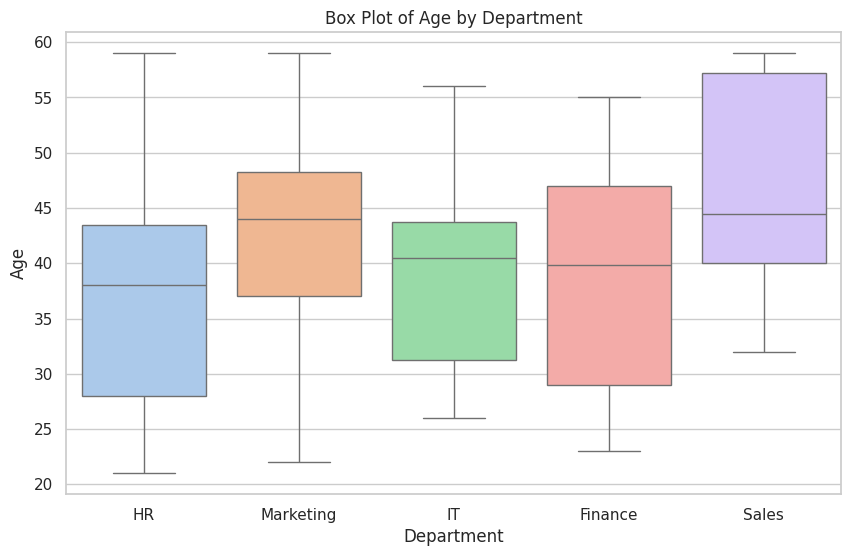

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
#Box Plot

sns.set(style="whitegrid")

#create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x='Department',y='Age',palette='pastel')

#set plot title and labels
plt.title('Box Plot of Age by Department',fontsize=12)
plt.xlabel('Department',fontsize=12)
plt.ylabel('Age',fontsize=12)

#show plot
plt.show()

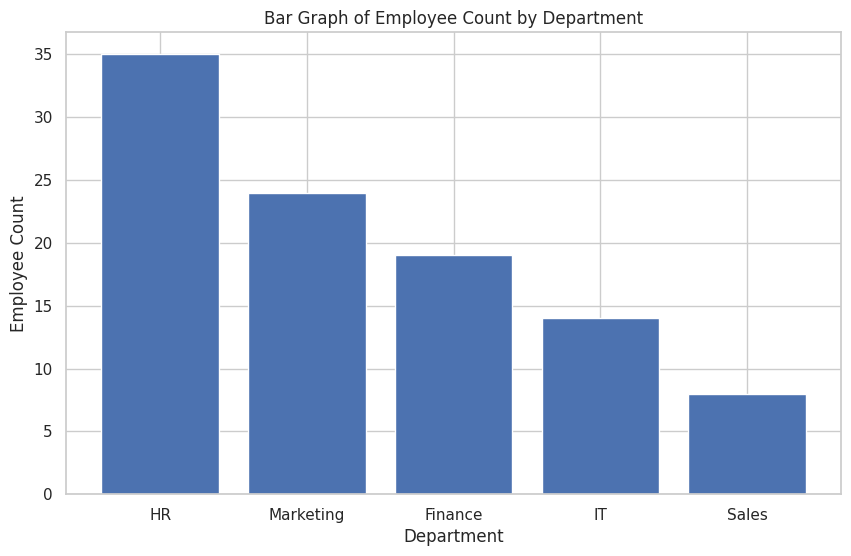

In [10]:
# Bar Graph using pure Matplotlib

# Calculate the counts for each department
dept_counts = df['Department'].value_counts()

# create bar graph
plt.figure(figsize=(10, 6))
plt.bar(x=dept_counts.index, height=dept_counts.values)

# set plot title and labels
plt.title('Bar Graph of Employee Count by Department', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Employee Count', fontsize=12)

# show plot
plt.show()

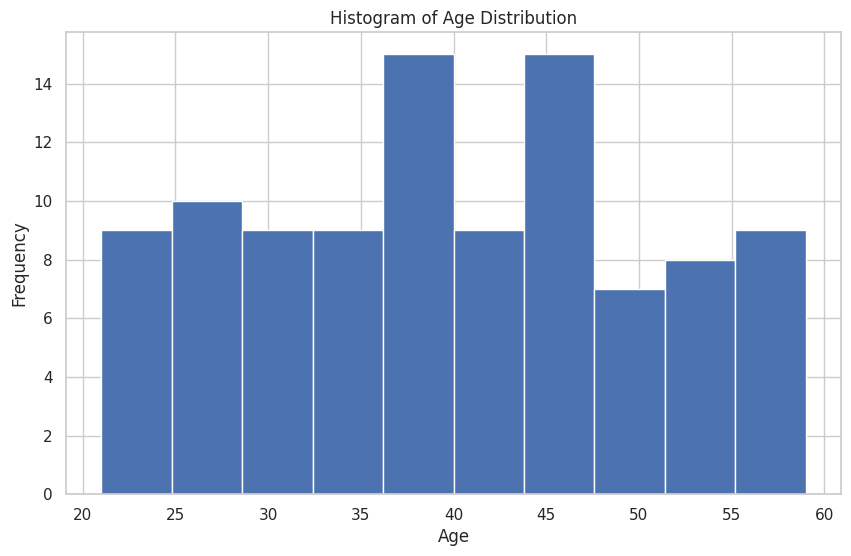

In [18]:
# Histogram using pure Matplotlib

# create histogram
plt.figure(figsize=(10, 6))
plt.hist(x=df['Age'].dropna())

# set plot title and labels
plt.title('Histogram of Age Distribution', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# show plot
plt.show()

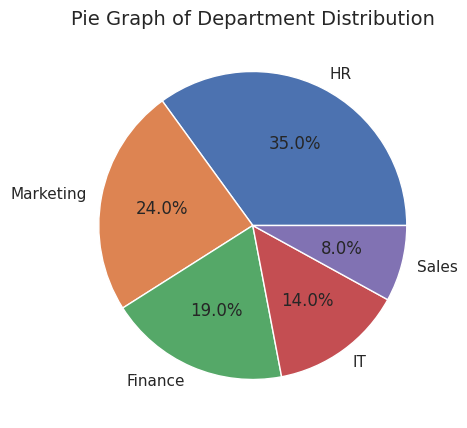

In [12]:
dept_counts = df['Department'].value_counts()

# 2. Create the pie chart
plt.figure(figsize=(5,5))
plt.pie(x=dept_counts.values,labels=dept_counts.index,autopct='%1.1f%%')

# 3. Add a title
plt.title('Pie Graph of Department Distribution', fontsize=14)

# 4. Show the chart
plt.show()

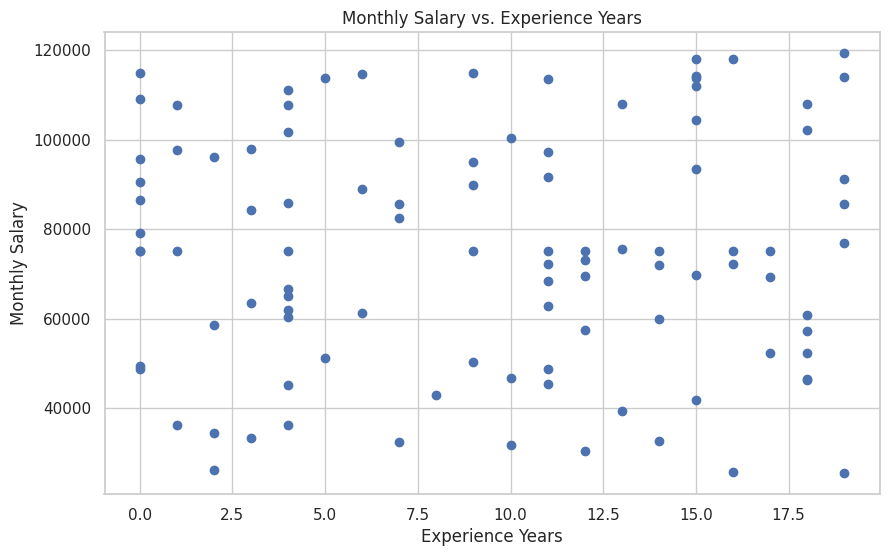

In [13]:
# Create dot graph
plt.figure(figsize=(10, 6))
plt.scatter(x=df['Experience_Years'], y=df['Monthly_Salary'])

# Add title
plt.title('Monthly Salary vs. Experience Years')
plt.xlabel('Experience Years')
plt.ylabel('Monthly Salary')

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
df['Gender_Label']=label_encoder.fit_transform(df['Gender'])

In [19]:
one_hot_encoded_data=pd.get_dummies(df['Department'],prefix='Department')
df=pd.concat([df,one_hot_encoded_data],axis=1)
encoded_data

NameError: name 'encoded_data' is not defined

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Initialize scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Min-Max Scaling
df['Age_MinMax'] = minmax_scaler.fit_transform(df[['Age']])
df['Monthly_Salary_MinMax'] = minmax_scaler.fit_transform(df[['Monthly_Salary']])

# Standard Scaling
df['Age_Standard'] = standard_scaler.fit_transform(df[['Age']])
df['Monthly_Salary_Standard'] = standard_scaler.fit_transform(df[['Monthly_Salary']])

# Robust Scaling
df['Age_Robust'] = robust_scaler.fit_transform(df[['Age']])
df['Monthly_Salary_Robust'] = robust_scaler.fit_transform(df[['Monthly_Salary']])

# Display results
df[['Age','Age_MinMax','Age_Standard','Age_Robust']].head()

,Age,Age_MinMax,Age_Standard,Age_Robust
0,59.0,1.000000,1.841242,1.254645
1,49.0,0.736842,0.878921,0.598907
2,35.0,0.368421,-0.468330,-0.319126
3,28.0,0.184211,-1.141955,-0.778142
4,41.0,0.526316,0.109063,0.074317


In [20]:
df

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition,...,Age_mean_imputed,Department_mode_imputed,Monthly_Salary_mean_imputed,Education_mode_imputed,City_mode_imputed,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Sales
0,1001,59.0,Male,HR,Masters,18,52350.0,5,Calicut,No,...,59.0,HR,52350.0,Masters,Calicut,False,True,False,False,False
1,1002,49.0,Female,Marketing,Bachelors,16,118008.0,2,Chennai,Yes,...,49.0,Marketing,118008.0,Bachelors,Chennai,False,False,False,True,False
2,1003,35.0,Female,HR,Masters,19,119297.0,1,Kochi,Yes,...,35.0,HR,119297.0,Masters,Kochi,False,True,False,False,False
3,1004,28.0,Female,HR,PhD,9,50351.0,2,Trivandrum,Yes,...,28.0,HR,50351.0,PhD,Trivandrum,False,True,False,False,False
4,1005,41.0,Male,IT,Bachelors,5,113668.0,3,Trivandrum,Yes,...,41.0,IT,113668.0,Bachelors,Trivandrum,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,54.0,Female,HR,Masters,11,48625.0,5,Chennai,Yes,...,54.0,HR,48625.0,Masters,Chennai,False,True,False,False,False
96,1097,53.0,Male,Marketing,Masters,13,107873.0,5,Trivandrum,Yes,...,53.0,Marketing,107873.0,Masters,Trivandrum,False,False,False,True,False
97,1098,43.0,Male,HR,PhD,1,97592.0,3,Chennai,No,...,43.0,HR,97592.0,PhD,Chennai,False,True,False,False,False
98,1099,44.0,Female,Marketing,PhD,18,102052.0,5,Calicut,Yes,...,44.0,Marketing,102052.0,PhD,Calicut,False,False,False,True,False
